In [1]:
# Week 1 - Day 1: IoT Telemetry Ingestion
# Dataset: AI4I 2020 Predictive Maintenance
# Intern: Sanjay R | Infotact DS/ML Internship

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [4]:
df = pd.read_csv(r'D:\predictive_maintenance\data\raw\ai4i2020.csv')
print("Dataset loaded!")
print("Shape:", df.shape)
df.head()

Dataset loaded!
Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
print("Column names:")
for col in df.columns:
    print(" -", col)

Column names:
 - UDI
 - Product ID
 - Type
 - Air temperature [K]
 - Process temperature [K]
 - Rotational speed [rpm]
 - Torque [Nm]
 - Tool wear [min]
 - Machine failure
 - TWF
 - HDF
 - PWF
 - OSF
 - RNF


In [6]:
print("Data types:")
print(df.dtypes)
print("\nNull values in each column:")
print(df.isnull().sum())

Data types:
UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Null values in each column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [7]:
print("Failure counts:")
print(df['Machine failure'].value_counts())
print(f"\nFailure rate: {df['Machine failure'].mean()*100:.2f}%")

Failure counts:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure rate: 3.39%


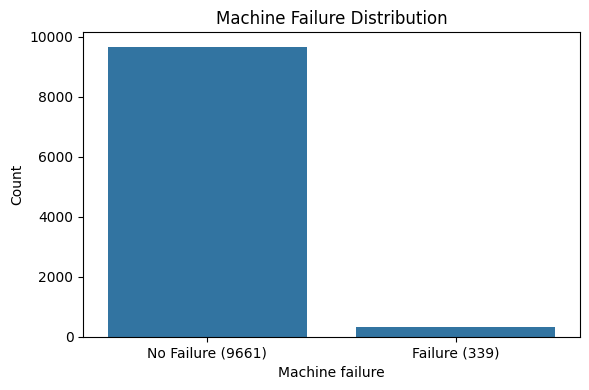

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Machine failure', data=df)
plt.title('Machine Failure Distribution')
plt.xticks([0,1], ['No Failure (9661)', 'Failure (339)'])
plt.ylabel('Count')
plt.tight_layout()
plt.show()

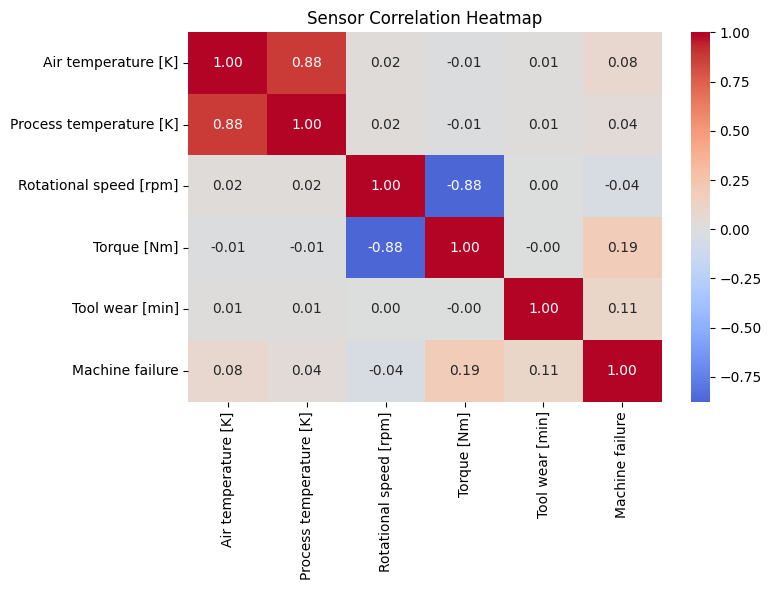

In [9]:
sensor_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Machine failure'
]

plt.figure(figsize=(8,6))
sns.heatmap(
    df[sensor_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Sensor Correlation Heatmap')
plt.tight_layout()
plt.show()

C:\Users\SANJAY R\AppData\Local\Temp\ipykernel_9772\2712002814.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine failure', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\SANJAY R\AppData\Local\Temp\ipykernel_9772\2712002814.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine failure', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\SANJAY R\AppData\Local\Temp\ipykernel_9772\2712002814.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine failure', y=col, data=df, ax=axes[i], palette='Set2')
C:\User

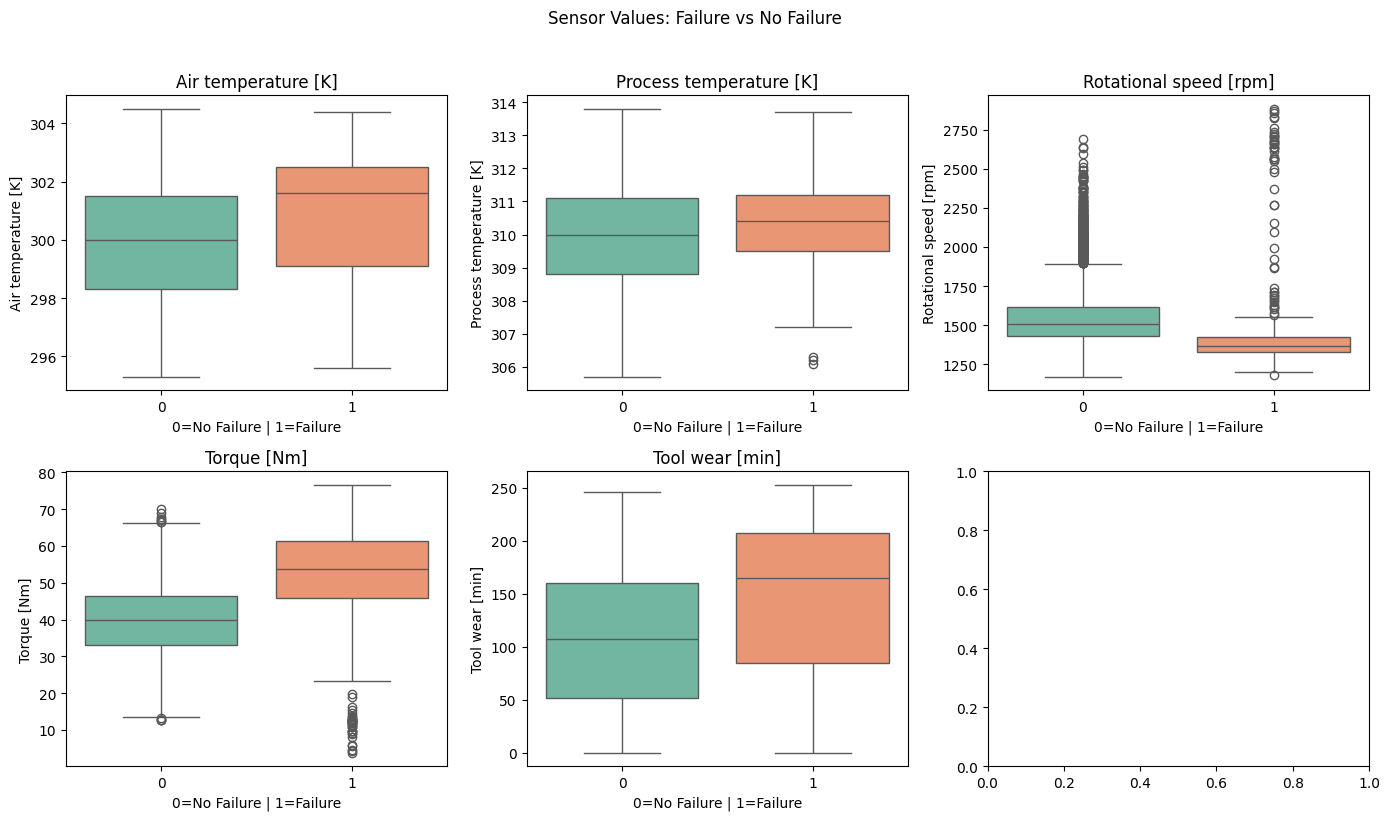

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14,8))
axes = axes.flatten()

for i, col in enumerate(sensor_cols[:-1]):
    sns.boxplot(x='Machine failure', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(col)
    axes[i].set_xlabel('0=No Failure | 1=Failure')

plt.suptitle('Sensor Values: Failure vs No Failure', y=1.02)
plt.tight_layout()
plt.show()

Failure Type Counts:
TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64


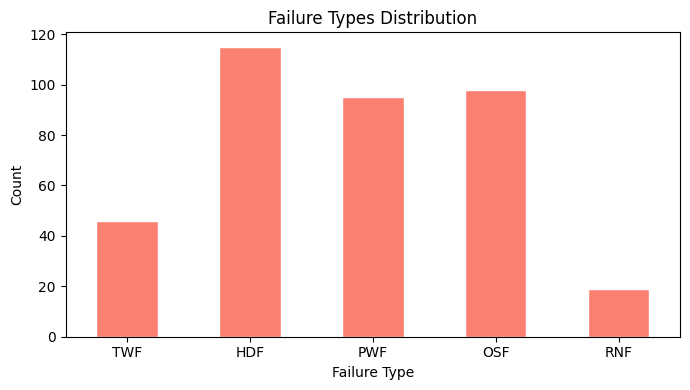

In [11]:
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

failure_counts = df[failure_cols].sum()
print("Failure Type Counts:")
print(failure_counts)

plt.figure(figsize=(7,4))
failure_counts.plot(kind='bar', color='salmon', edgecolor='white')
plt.title('Failure Types Distribution')
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
sensor_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

print("Sensor columns ready for feature engineering:")
for col in sensor_cols:
    print(" -", col)

Sensor columns ready for feature engineering:
 - Air temperature [K]
 - Process temperature [K]
 - Rotational speed [rpm]
 - Torque [Nm]
 - Tool wear [min]


In [13]:
windows = [3, 5, 10]

for col in sensor_cols:
    short = col.split(' ')[0].lower()
    for w in windows:
        df[f'{short}_roll{w}_mean'] = df[col].rolling(window=w).mean()
        df[f'{short}_roll{w}_std']  = df[col].rolling(window=w).std()
        df[f'{short}_roll{w}_var']  = df[col].rolling(window=w).var()

print("Rolling features created!")
print("New shape:", df.shape)
print("New features added:", df.shape[1] - 14)

Rolling features created!
New shape: (10000, 59)
New features added: 45


In [14]:
for col in sensor_cols:
    short = col.split(' ')[0].lower()
    df[f'{short}_lag1'] = df[col].shift(1)
    df[f'{short}_lag2'] = df[col].shift(2)

print("Lag features created!")
print("New shape:", df.shape)

Lag features created!
New shape: (10000, 69)


In [15]:
before = len(df)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
after = len(df)

print(f"Rows before : {before}")
print(f"Rows after  : {after}")
print(f"Rows removed: {before - after}")
print(f"Final shape : {df.shape}")

Rows before : 10000
Rows after  : 9991
Rows removed: 9
Final shape : (9991, 69)


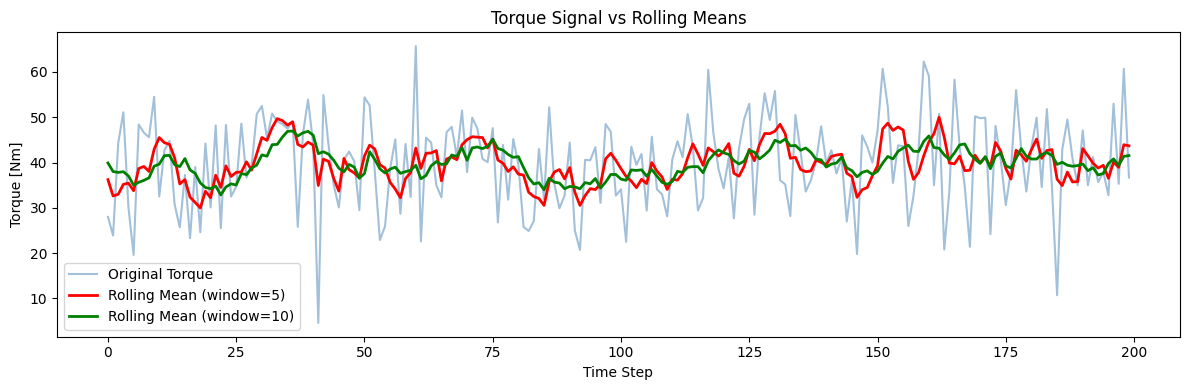

In [16]:
plt.figure(figsize=(12,4))

plt.plot(df['Torque [Nm]'][:200],
         label='Original Torque', alpha=0.5, color='steelblue')
plt.plot(df['torque_roll5_mean'][:200],
         label='Rolling Mean (window=5)', color='red', linewidth=2)
plt.plot(df['torque_roll10_mean'][:200],
         label='Rolling Mean (window=10)', color='green', linewidth=2)

plt.title('Torque Signal vs Rolling Means')
plt.xlabel('Time Step')
plt.ylabel('Torque [Nm]')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
np.random.seed(42)

df['ambient_humidity']   = np.random.uniform(30, 90, len(df))
df['factory_load_index'] = np.random.uniform(0, 100, len(df))
df['shift_period']       = (df.index % 48 < 24).astype(int)

print("External contextual signals added!")
print("Final shape:", df.shape)
df[['ambient_humidity', 'factory_load_index', 'shift_period']].describe().round(2)

External contextual signals added!
Final shape: (9991, 72)


,ambient_humidity,factory_load_index,shift_period
count,9991.00,9991.00,9991.0
mean,59.65,50.45,0.5
std,17.26,28.93,0.5
min,30.00,0.02,0.0
25%,44.78,25.39,0.0
50%,59.55,50.59,1.0
75%,74.37,75.64,1.0
max,89.98,99.99,1.0


In [19]:
save_path = r'D:\predictive_maintenance\data\processed\ai4i2020_processed.csv'
df.to_csv(save_path, index=False)
print("Processed dataset saved successfully!")
print(f"Location : {save_path}")
print(f"Final shape: {df.shape}")

Processed dataset saved successfully!
Location : D:\predictive_maintenance\data\processed\ai4i2020_processed.csv
Final shape: (9991, 72)


In [20]:
print("=" * 50)
print("  WEEK 1 COMPLETE - FINAL SUMMARY")
print("=" * 50)
print(f"  Original features      : 14")
print(f"  Rolling features added : 45")
print(f"  Lag features added     : 10")
print(f"  External signals added : 3")
print(f"  Total features         : {df.shape[1]}")
print(f"  Total rows             : {df.shape[0]}")
print(f"  Failure rate preserved : {df['Machine failure'].mean()*100:.2f}%")
print("=" * 50)
print("  processed_data.csv saved to data/processed/")
print("  Ready for Week 2: SMOTE + LightGBM Modeling!")
print("=" * 50)

  WEEK 1 COMPLETE - FINAL SUMMARY
  Original features      : 14
  Rolling features added : 45
  Lag features added     : 10
  External signals added : 3
  Total features         : 72
  Total rows             : 9991
  Failure rate preserved : 3.39%
  processed_data.csv saved to data/processed/
  Ready for Week 2: SMOTE + LightGBM Modeling!
